In [163]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [164]:
def f(x):
    return 5 * x**2 + 3 * x + 1

In [165]:
f(2.0)

27.0

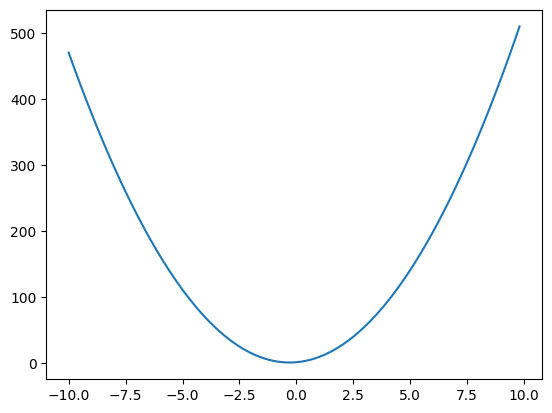

In [166]:
xs = np.arange(-10, 10, 0.2)
ys = f(xs)
plt.plot(xs, ys)

In [167]:
h = 0.001
x = 2.0
(f(x + h) - f(x)) / h

23.00499999999772

In [168]:
a = 3.0
b = -4.0
c = 5.0
d = a * b + c
d

-7.0

In [169]:
h = 0.001
a = 3.0
b = -4.0
c = 5.0

d1 = a * b + c
a += h
d2 = a * b + c

print("d1:", d1)
print("d2:", d2)
print("dd/da:", (d2 - d1) / h)

d1: -7.0
d2: -7.004
dd/da: -3.9999999999995595


In [170]:
b += h
d3 = a * b + c
print("d3:", d3)
print("dd/db:", (d3 - d2) / h)

d3: -7.000999
dd/db: 3.0009999999993653


In [171]:
class Value:
    def __init__(self, data, _children=(), op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self.op = op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, op={self.op})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), op="+")
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), op="*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), op="**")
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __rtruediv__(self, other):
        return other * self**-1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), op="tanh")
        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), op="exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        for v in topo:
            v.grad = 0.0
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

In [172]:
from html import escape
from shutil import which

try:
    from graphviz import Digraph
except ModuleNotFoundError:
    Digraph = None

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_svg(nodes, edges):
    children = {node: [] for node in nodes}
    for src, dst in edges:
        children[dst].append(src)

    def depth(node):
        if not children[node]:
            return 0
        return 1 + max(depth(child) for child in children[node])

    levels = {}
    for node in nodes:
        levels.setdefault(depth(node), []).append(node)

    width = max(300, 280 * (max(levels) + 1))
    height = max(220, 130 * max(len(level) for level in levels.values()))
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<defs><marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth"><path d="M0,0 L0,6 L9,3 z" fill="#555" /></marker></defs>',
        '<style>text{font-family:Menlo,Consolas,monospace;font-size:12px}.node{fill:#fff;stroke:#333;stroke-width:1.5px}.op{fill:#f6f6f6;stroke:#333;stroke-width:1.5px}.edge{stroke:#555;stroke-width:1.5px;fill:none;marker-end:url(#arrow)}</style>',
    ]
    positions = {}
    for level, level_nodes in levels.items():
        for row, node in enumerate(level_nodes):
            x = 25 + level * 280
            y = 35 + row * 125
            positions[node] = (x, y)
            label_text = escape(getattr(node, "label", ""))
            data_label = escape(f'data {node.data:.4f}')
            grad_label = escape(f'grad {getattr(node, "grad", 0.0):.4f}')
            parts.append(f'<rect class="node" x="{x}" y="{y}" width="170" height="82" rx="4" />')
            if label_text:
                parts.append(f'<text x="{x + 10}" y="{y + 22}">{label_text}</text>')
                parts.append(f'<text x="{x + 10}" y="{y + 46}">{data_label}</text>')
                parts.append(f'<text x="{x + 10}" y="{y + 68}">{grad_label}</text>')
            else:
                parts.append(f'<text x="{x + 10}" y="{y + 34}">{data_label}</text>')
                parts.append(f'<text x="{x + 10}" y="{y + 58}">{grad_label}</text>')
            if node.op:
                op_x = x - 55
                op_y = y + 26
                positions[("op", node)] = (op_x, op_y)
                parts.append(f'<circle class="op" cx="{op_x + 15}" cy="{op_y + 15}" r="15" />')
                parts.append(f'<text x="{op_x + 10}" y="{op_y + 20}">{escape(node.op)}</text>')
                parts.append(f'<path class="edge" d="M{op_x + 30},{op_y + 15} L{x},{y + 41}" />')
    for src, dst in edges:
        x1, y1 = positions[src]
        if dst.op:
            x2, y2 = positions[("op", dst)]
            parts.append(f'<path class="edge" d="M{x1 + 170},{y1 + 41} L{x2},{y2 + 15}" />')
        else:
            x2, y2 = positions[dst]
            parts.append(f'<path class="edge" d="M{x1 + 170},{y1 + 41} L{x2},{y2 + 41}" />')
    parts.append('</svg>')
    return ''.join(parts)

def node_label(n):
    label = getattr(n, "label", "")
    data = f"data {n.data:.4f}"
    grad = f"grad {getattr(n, 'grad', 0.0):.4f}"
    if label:
        return f"{{ {label} | {data} | {grad} }}"
    return f"{{ {data} | {grad} }}"

def draw_dot(root):
    from IPython.display import SVG

    nodes, edges = trace(root)
    if Digraph is None or which("dot") is None:
        return SVG(draw_svg(nodes, edges))

    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})
    for n in nodes:
        dot.node(name=str(id(n)), label=node_label(n), shape="record")
        if n.op:
            dot.node(name=str(id(n)) + n.op, label=n.op)
            dot.edge(str(id(n)) + n.op, str(id(n)))
    for src, dst in edges:
        if dst.op:
            dot.edge(str(id(src)), str(id(dst)) + dst.op)
        else:
            dot.edge(str(id(src)), str(id(dst)))
    return dot

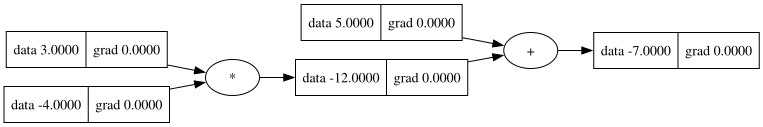

In [173]:
def test_draw_dot():
    a = Value(3.0)
    b = Value(-4.0)
    c = Value(5.0)
    d = a * b + c
    return draw_dot(d)
test_draw_dot()

In [174]:
def test_grad():
    h = 0.001
    a = Value(3.0)
    b = Value(-4.0)
    c = Value(5.0)
    d = a * b + c
    d1 = d.data

    a = Value(3.0 + h)
    b = Value(-4.0)
    c = Value(5.0)
    d = a * b + c
    d2 = d.data
    print("dd/da:", (d2 - d1) / h)
    
test_grad()



dd/da: -3.9999999999995595


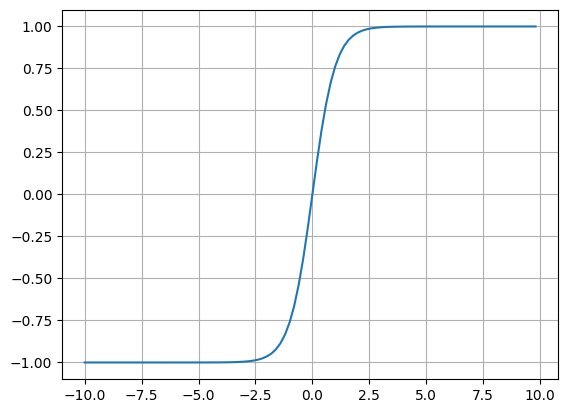

In [175]:
plt.plot(np.arange(-10, 10, 0.2), np.tanh(np.arange(-10, 10, 0.2))); plt.grid();

In [176]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1
x1w1.label = "x1*w1"
x2w2 = x2 * w2
x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b
n.label = "n"
o = n.tanh()
o.label = "o"


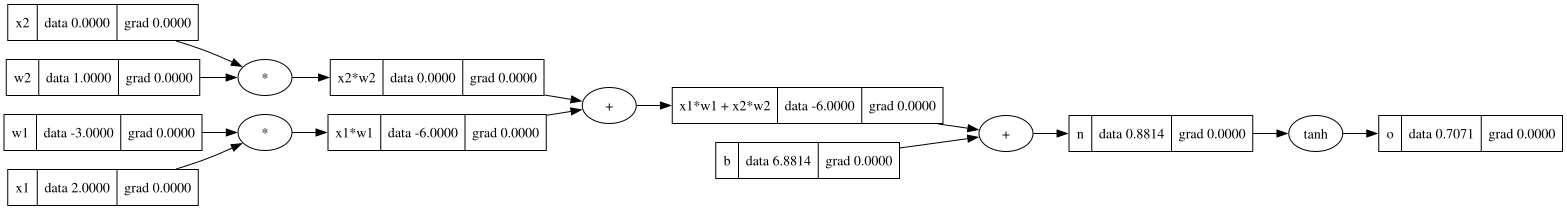

In [177]:
draw_dot(o)

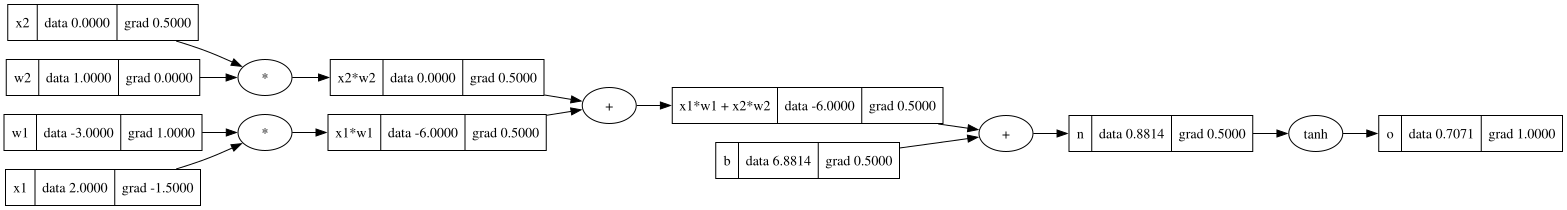

In [178]:
for node in trace(o)[0]:
    node.grad = 0.0
o.grad = 1.0
o.backward() 
draw_dot(o)

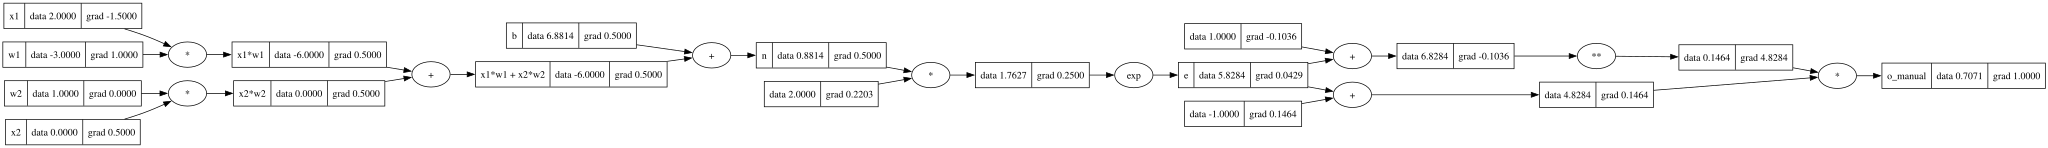

In [179]:
# manual tanh using exp and primitive ops
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1
x1w1.label = "x1*w1"
x2w2 = x2 * w2
x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b
n.label = "n"

e = (2 * n).exp()
e.label = "e"
o_manual = (e - 1) / (e + 1)
o_manual.label = "o_manual"

o_manual.backward()
draw_dot(o_manual)

In [180]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        self.layers = [Layer(sizes[i], sizes[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [181]:
random.seed(1337)
x = [2.0, 3.0, -1.0]
n = Neuron(3)
n(x)

Value(data=0.8042330078305038, op=tanh)

In [182]:
random.seed(1337)
x = [2.0, 3.0, -1.0]
model = MLP(3, [4, 4, 1])
ypred = model(x)
ypred.label = "ypred"
ypred

Value(data=0.42767811248845455, op=tanh)

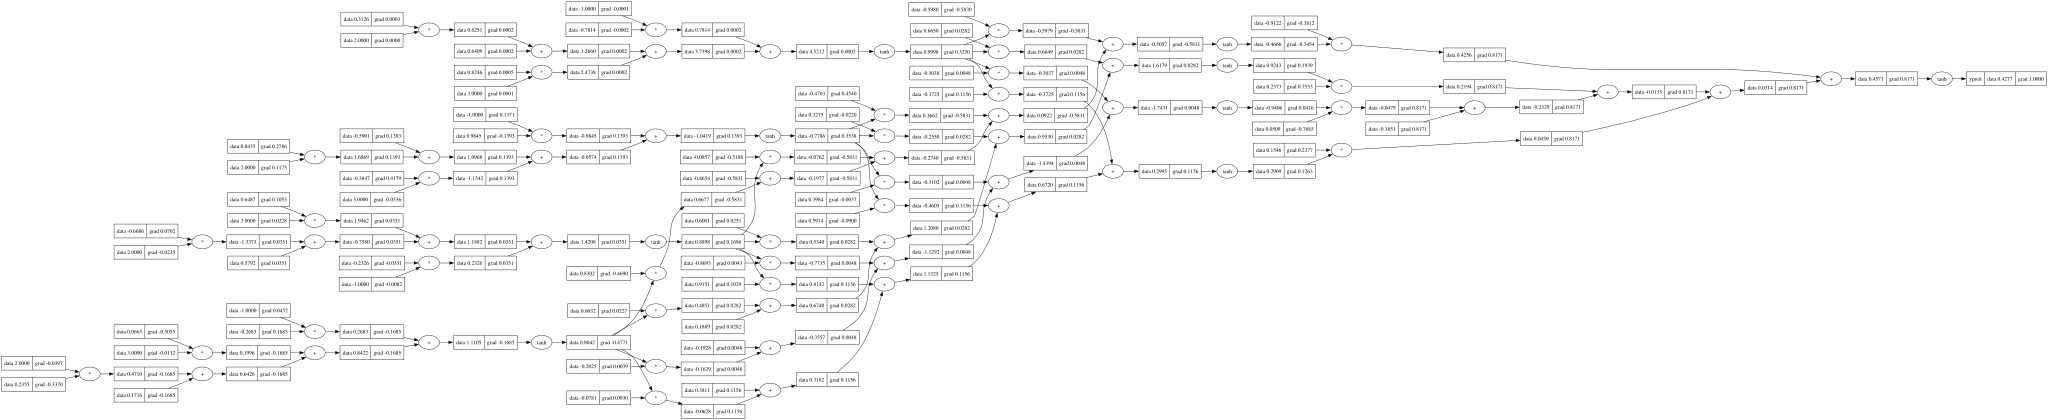

In [183]:
ypred.backward()
draw_dot(ypred)

In [184]:
random.seed(1337)
model = MLP(3, [4, 4, 1])

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

ypred = [model(x) for x in xs]
ypred

[Value(data=0.42767811248845455, op=tanh),
 Value(data=0.5570649429984824, op=tanh),
 Value(data=0.7184669978530105, op=tanh),
 Value(data=0.45203067521739915, op=tanh)]

In [ ]:
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
loss.label = "loss"
loss

Value(data=6.005402783252284, op=+)

In [186]:
loss.backward()
model.parameters()[0].grad

-0.4536648933083659

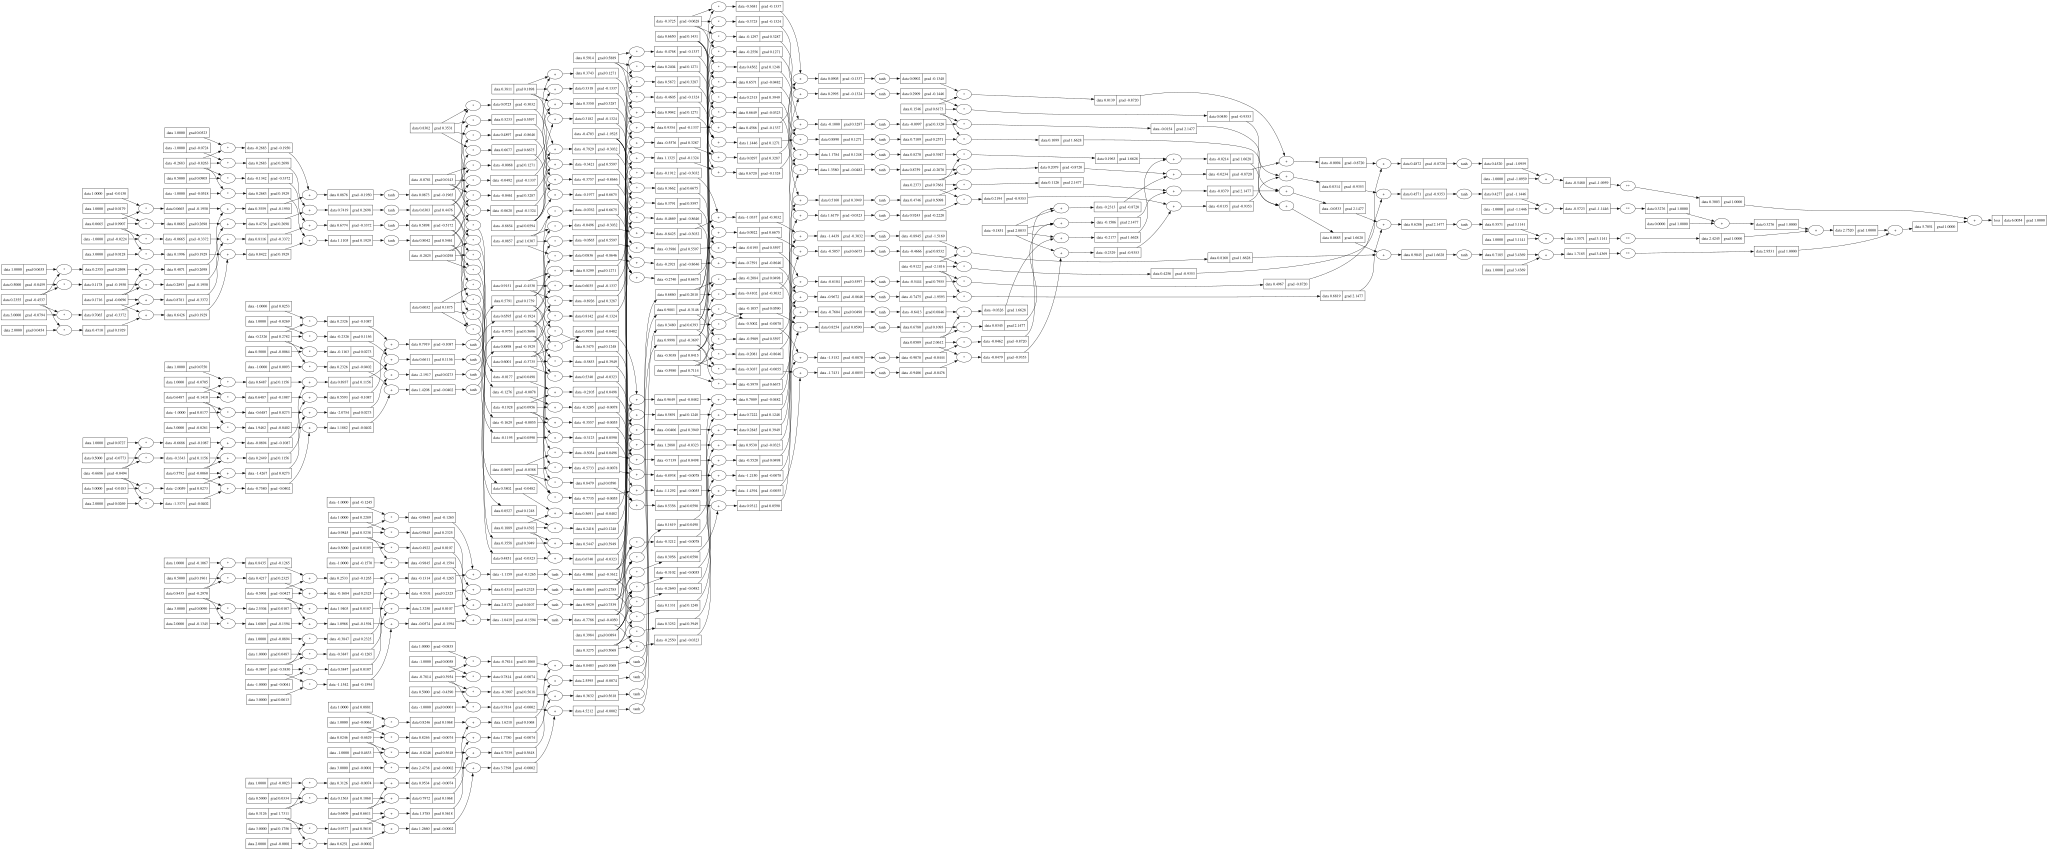

In [187]:
draw_dot(loss)

In [190]:
for p in model.parameters():
    p.data += -0.01 * p.grad
ypred = [model(x) for x in xs]
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
loss

Value(data=5.711631170667038, op=+)